# A/B Testing Project

In [ ]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import scipy.stats as stats
import numpy as np

In [2]:
control = pd.read_csv(r"data\control_group.csv", sep=';')
control.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
test = pd.read_csv(r"data\test_group.csv", sep=';')
test.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


# 1.0 Data Cleaning

In [4]:
control.rename(columns={'Campaign Name': 'campaign_name',
                        'Date': 'date', 
                        'Spend [USD]': 'spend_usd', 
                        '# of Impressions': 'number of impressions',
                        'Reach': 'reach',
                        '# of Website Clicks': 'number_of_clicks',
                        '# of Searches': 'number_of_searches',
                        '# of View Content': 'number_of_view_content',
                        '# of Add to Cart': 'number_of_add_to_cart',
                        '# of Purchase': 'number_of_purchase'}, inplace=True)

test.rename(columns={'Campaign Name': 'campaign_name',
                        'Date': 'date', 
                        'Spend [USD]': 'spend_usd', 
                        '# of Impressions': 'number of impressions',
                        'Reach': 'reach',
                        '# of Website Clicks': 'number_of_clicks',
                        '# of Searches': 'number_of_searches',
                        '# of View Content': 'number_of_view_content',
                        '# of Add to Cart': 'number_of_add_to_cart',
                        '# of Purchase': 'number_of_purchase'}, inplace=True)

In [5]:
control['date'] = pd.to_datetime(control['date'], format='%d.%m.%Y')
test['date'] = pd.to_datetime(test['date'], format='%d.%m.%Y')

## 1.1 Handling Missing Values

In [6]:
control[control.isna().any(axis=1)]

,campaign_name,date,spend_usd,number of impressions,reach,number_of_clicks,number_of_searches,number_of_view_content,number_of_add_to_cart,number_of_purchase
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For the the control group, there is only 1 row of missing data. However since, the information of USD spent is important, we won't be removing it rather we would set the missing data as '0'.

In [7]:
control = control.fillna(0)

In [8]:
control.iloc[4]

campaign_name                Control Campaign
date                      2019-08-05 00:00:00
spend_usd                                1835
number of impressions                     0.0
reach                                     0.0
number_of_clicks                          0.0
number_of_searches                        0.0
number_of_view_content                    0.0
number_of_add_to_cart                     0.0
number_of_purchase                        0.0
Name: 4, dtype: object

In [9]:
test[test.isna().any(axis=1)]

,campaign_name,date,spend_usd,number of impressions,reach,number_of_clicks,number_of_searches,number_of_view_content,number_of_add_to_cart,number_of_purchase


There are no missing values in the test group

# 2.0 Exploratory Data Analysis

### 2.1 USD Spent on Each Group

In [10]:
control_spent = control['spend_usd'].sum()
test_spent = test['spend_usd'].sum()

print(f"Total Spent for Control Group: ${control_spent}")
print(f"Total Spent for Test Group: ${test_spent}")


Total Spent for Control Group: $68653
Total Spent for Test Group: $76892


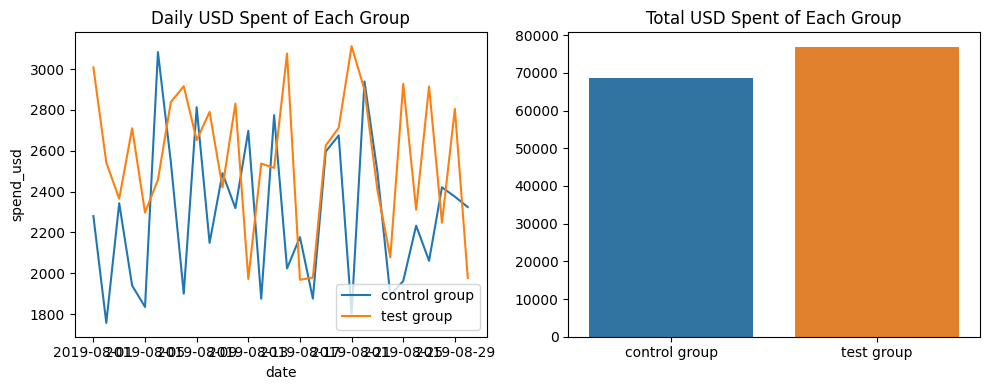

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x_spend = ['control group', 'test group']
y_spend = [control_spent, test_spent]
sns.barplot(x=x_spend, y=y_spend, hue=x_spend, ax=axes[1])
axes[1].set_title("Total USD Spent of Each Group")

sns.lineplot(data=control, x='date', y='spend_usd', label='control group', ax=axes[0])
sns.lineplot(data=test, x='date', y='spend_usd', label='test group', ax=axes[0])
axes[0].set_title("Daily USD Spent of Each Group")

plt.tight_layout()

In [12]:
print(f"There is an increase of {round((test_spent - control_spent)/(test_spent + control_spent) * 100,2)}% in expenses by the Test Group")

There is an increase of 5.66% in expenses by the Test Group


We can see that the test groups shows higher USD spent than the control group with a jump of 6% in expense for the test group

### 2.2 Comparing Number of Purchases

In [13]:
control_purchase = control['number_of_purchase'].sum()
test_purchase = test['number_of_purchase'].sum()

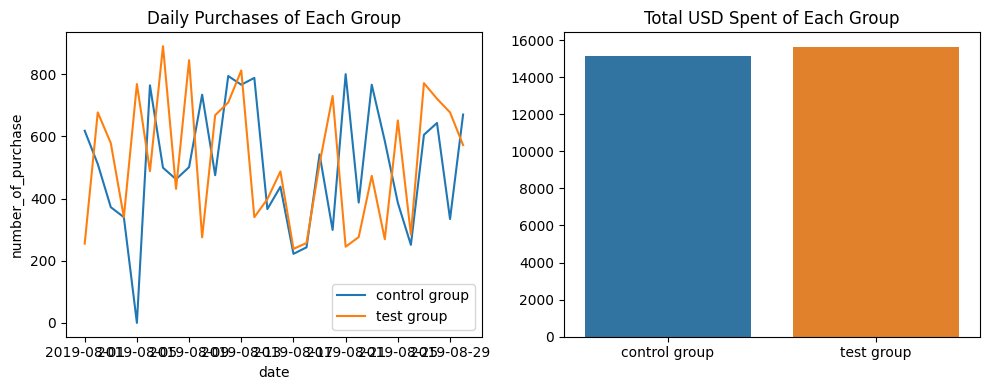

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x_spend = ['control group', 'test group']
y_spend = [control_purchase, test_purchase]
sns.barplot(x=x_spend, y=y_spend, hue=x_spend, ax=axes[1])
axes[1].set_title("Total USD Spent of Each Group")

sns.lineplot(data=control, x='date', y='number_of_purchase', label='control group', ax=axes[0])
sns.lineplot(data=test, x='date', y='number_of_purchase', label='test group', ax=axes[0])
axes[0].set_title("Daily Purchases of Each Group")

plt.tight_layout()

In [15]:
print(f"There is an increase of {round((test_purchase - control_purchase)/(test_purchase + control_purchase) * 100,2)}% in purchases by the Test Group")

There is an increase of 1.55% in purchases by the Test Group


We can see that the test groups shows higher purchases than the control group with a jump of 2% in purchases for the test group

From these two analysis we can conclude that the test group is more expensive and give a slight improvement in purchases, however such conclusion would need further testing and analysis. Therefore, we would move on with the funnel analysis to discover more information regarding the data.

# 3.0 Funnel Analysis

In [16]:
funnel_columns = [
    'number of impressions',
    'reach',
    'number_of_clicks',
    'number_of_searches',
    'number_of_view_content',
    'number_of_add_to_cart',
    'number_of_purchase'
]

stage_names = [
    'Impressions', 
    'Reach', 
    'Clicks', 
    'Searches', 
    'View Content', 
    'Add to Cart', 
    'Purchase'
]

# Aggregate the 30 days of data by summing the columns
control_totals = [control[col].sum() for col in funnel_columns]
test_totals = [test[col].sum() for col in funnel_columns]

funnel_df = pd.DataFrame({
    'Stage': stage_names,
    'Control_Volume': control_totals,
    'Test_Volume': test_totals
})

# Calculate step-by-step Conversion Rates
def calculate_step_conversion(volume_list):
    rates = [100.0]
    for i in range(1, len(volume_list)):
        current_val = volume_list[i]
        previous_val = volume_list[i-1]
        
        rate = (current_val / previous_val) * 100 if previous_val > 0 else 0.0
        rates.append(round(rate, 2))
    return rates

funnel_df['Control_Conversion_From_Prev_%'] = calculate_step_conversion(control_totals)
funnel_df['Test_Conversion_From_Prev_%'] = calculate_step_conversion(test_totals)

print("--- Funnel Data & Step-by-Step Conversion Rates ---")
print(funnel_df.to_string(index=False))
print("\n")

# === Visualization ===
fig = go.Figure()

fig.add_trace(go.Funnel(
    name = 'Control Campaign',
    y = stage_names,
    x = control_totals,
    textinfo = "value+percent previous",
    marker = {"color": "#1f77b4"}
))

fig.add_trace(go.Funnel(
    name = 'Test Campaign',
    y = stage_names,
    x = test_totals,
    textinfo = "value+percent previous",
    marker = {"color": "#ff7f0e"}
))

fig.update_layout(
    title_text="Funnel Drop-off Analysis: Control vs. Test",
    title_x=0.5,
    funnelmode="group",
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show(renderer="browser")

--- Funnel Data & Step-by-Step Conversion Rates ---
       Stage  Control_Volume  Test_Volume  Control_Conversion_From_Prev_%  Test_Conversion_From_Prev_%
 Impressions       3177233.0      2237544                          100.00                       100.00
       Reach       2576503.0      1604747                           81.09                        71.72
      Clicks        154303.0       180970                            5.99                        11.28
    Searches         64418.0        72569                           41.75                        40.10
View Content         56370.0        55740                           87.51                        76.81
 Add to Cart         37700.0        26446                           66.88                        47.45
    Purchase         15161.0        15637                           40.21                        59.13




The key insight from the funnel analysis is that the Test group has a higher click rate than the Control group. This indicates that people are more intrigued by the Test group's advertisement (it may be more "clickbaity"). While this sounds like a better approach at first, it fails at getting these users to actually add items to their cart. The conversion rate drops sharply to 47.45% at this stage, which shows the ad might be so clickbaity that when customers finally see the actual product, they just leave.

# 4.0 Hypothesis  Testing

As previously mentioned, in this section we will be testing on whether the 2% jump of the Test Group is a true significant jump or is it just a random jump.

In [27]:
# Creating conversion rates (impression -> purchase)
control['conv_rate'] = control['number of impressions'] / control['number_of_purchase']
test['conv_rate'] = test['number of impressions'] / test['number_of_purchase']

control = control.fillna(0)
control.head()

,campaign_name,date,spend_usd,number of impressions,reach,number_of_clicks,number_of_searches,number_of_view_content,number_of_add_to_cart,number_of_purchase,conv_rate
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,133.822006
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,236.868885
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,354.061828
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,214.347059
4,Control Campaign,2019-08-05,1835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [ ]:
# Normality Assumption Checking
stat_control, p_norm_control = shapiro(control['conv_rate'])
stat_test, p_norm_test = shapiro(test['conv_rate'])

print(f"Test Statistic of the Control Group: {stat_control}\nP-Value of the Control Group: {p_norm_control}")
print(f"\nTest Statistic of the Test Group: {stat_test}\nP-Value of the Test Group: {p_norm_test}")

Test Statistic of the Normal Group: 0.9408091279455701
P-Value of the Normal Group: 0.09564020450924703

Test Statistic of the Test Group: 0.8484526410697392
P-Value of the Test Group: 0.0005755611810417117


Text(0.5, 1.0, "Normal QQ Plot of the 'Test' Group")

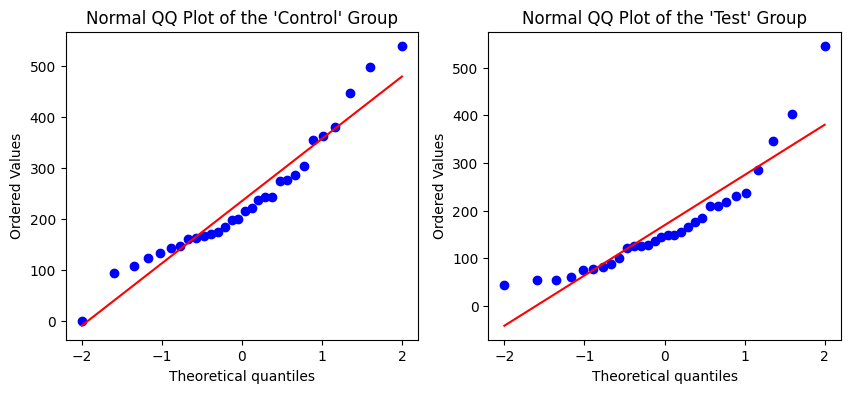

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(control['conv_rate'], dist="norm", plot=axes[0])
axes[0].set_title("Normal QQ Plot of the 'Control' Group")

stats.probplot(test['conv_rate'], dist="norm", plot=axes[1])
axes[1].set_title("Normal QQ Plot of the 'Test' Group")


We can see that the Test Group failed the normality check since its p-value < 0.05 and the QQ plot shows that the points does not fall near to the reference line. Therefore, we won't use t-test as it assumes normality. Hence, we will proceed  with Mann-Whitney U Test and Bootstrapping

In [ ]:
# Mann-Whitney U Test
u_stat, p_val = mannwhitneyu(test['conv_rate'], control['conv_rate'], alternative='greater')
print(f"Mann-Whitney U Statistic: {u_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant! Reject the Null Hypothesis.")
else:
    print("Result: Not Statistically Significant. Fail to Reject the Null Hypothesis.")


Mann-Whitney U Statistic: 275.0000
p-value: 0.9953
Result: Not Statistically Significant. Fail to Reject the Null Hypothesis.


In [ ]:
np.random.seed(42)

# Calculate the observed difference in means
diff_observed = test['conv_rate'].mean() - control['conv_rate'].mean()

# Bootstrap 10,000 times
boot_diffs = []
for _ in range(10000):
    boot_control = np.random.choice(control['conv_rate'], size=len(control), replace=True)
    boot_test = np.random.choice(test['conv_rate'], size=len(test), replace=True)
    boot_diffs.append(np.mean(boot_test) - np.mean(boot_control))

# Calculate 95% Confidence Interval
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print(f"Observed Difference in Mean CVR: {diff_observed:.4%}")
print(f"95% Bootstrapped Confidence Interval: [{ci_lower:.4%}, {ci_upper:.4%}]")

if ci_lower > 0:
    print("Result: Statistically Significant! The 95% CI does not include 0.")
else:
    print("Result: Not Statistically Significant. The 95% CI includes 0.")

Observed Difference in Mean CVR: -6511.9480%
95% Bootstrapped Confidence Interval: [-12373.7955%, -903.0676%]
Result: Not Statistically Significant. The 95% CI includes 0.


Here I performed a Mann-Whitney U Test and Bootstrapped Resampling to evaluate whether the difference in conversion performance between the Control and Test campaigns was statistically significant. Both of the tests yielded insignificancy, which conclude that the improvement of purchase in Test Group is not significant.

# 5.0 Conclusion

**Key Findings:**
* The Test group achieved higher raw purchase numbers (15,637 vs 15,161), the 6% increase in total spend resulted in a higher Cost Per Acquisition (CPA) for the business.
* The Test campaign was incredibly successful at capturing attention, driving a massive 11.28% Click-Through Rate (CTR) compared to the Control's 5.99%.
* The Funnel analysis revealed a major friction point. In the Control group, 66.88% of users who viewed content proceeded to add items to their cart. In the Test group, this plummeted to 47.45%. This suggests the Test ad creative sets expectations that the landing page or product pricing fails to meet.

**Recommendations:**
* Do not scale the Test Campaign, since rolling out this campaign will decrease marketing efficiency and raise the overall CPA without a guaranteed increase in sales.
* The marketing team should combine the winning elements of both campaigns. We should use the highly engaging Ad Creative from the Test Campaign (to leverage the 11% CTR), but route users to the Control Campaign's landing page/funnel flow (to preserve the superior 67% Add-to-Cart retention rate).
* The UX/UI team should investigate the transition from the Test ad to the website. The steep drop-off at the "View Content" stage suggests a disconnect between the ad's promise and the product page reality.